In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint,uniform
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, confusion_matrix,classification_report

In [4]:
df = pd.read_csv(r"G:\My Drive\Credit Card Anomaly Detection\data\raw\creditcard.csv")

separate X and y

In [5]:
X = df.drop(columns='Class')
y = df['Class']

In [6]:
print(X.shape)
print(y.shape)

(284807, 30)
(284807,)


Train test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

scale the features

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 1. Logistic Regression baseline

In [9]:
log_reg = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Prediction

In [10]:
y_pred = log_reg.predict(X_test_scaled)

y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

In [11]:
y_prob

array([0.00569098, 0.06755242, 0.00011903, ..., 0.00026008, 0.00375493,
       0.08229136], shape=(56962,))

Evaluation

In [12]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
pr_auc = average_precision_score(y_test, y_prob)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("PR-AUC:", pr_auc)

Precision: 0.06097560975609756
Recall: 0.9183673469387755
F1-score: 0.11435832274459974
PR-AUC: 0.7189705771419241


In [13]:
#classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [14]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[55478  1386]
 [    8    90]]


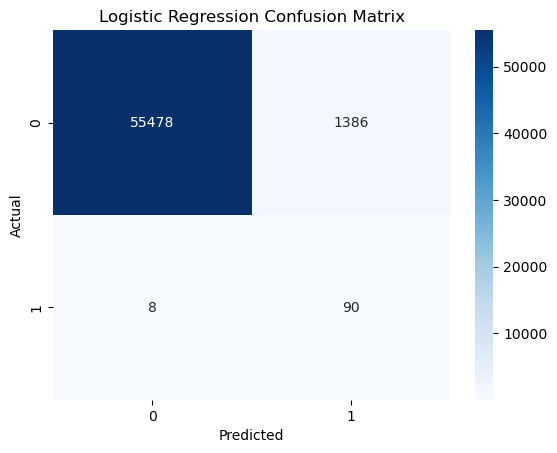

In [15]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

Baseline resuts

In [16]:
baseline_results = {
    "Model": "Logistic Regression",
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "PR-AUC": pr_auc
}

print(baseline_results)

{'Model': 'Logistic Regression', 'Precision': 0.06097560975609756, 'Recall': 0.9183673469387755, 'F1': 0.11435832274459974, 'PR-AUC': 0.7189705771419241}


## 2. Random Forest

In [17]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Prediction

In [18]:
y_pred_rf = rf.predict(X_test)

y_prob_rf = rf.predict_proba(X_test)[:, 1]

Evaluate

In [19]:
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
pr_auc_rf = average_precision_score(y_test, y_prob_rf)

print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1-score:", f1_rf)
print("PR-AUC:", pr_auc_rf)

Precision: 0.9605263157894737
Recall: 0.7448979591836735
F1-score: 0.8390804597701149
PR-AUC: 0.8541999432510914


In [20]:
#classificatio report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



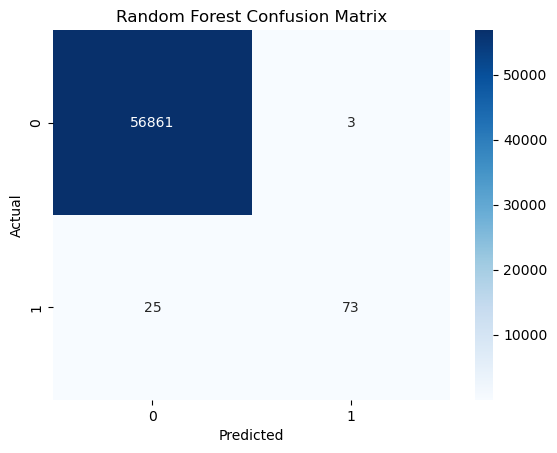

In [21]:
#confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

random forest results

In [22]:
rf_results = {
    "Model": "Random Forest",
    "Precision": precision_rf,
    "Recall": recall_rf,
    "F1": f1_rf,
    "PR-AUC": pr_auc_rf
}

print(rf_results)

{'Model': 'Random Forest', 'Precision': 0.9605263157894737, 'Recall': 0.7448979591836735, 'F1': 0.8390804597701149, 'PR-AUC': 0.8541999432510914}


### Tuning

In [ ]:
#instantiate model
rf_tuning = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [ ]:
#defining parameters
param_dist = {
    "n_estimators": randint(100, 500),
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 5),
    "max_features": ["sqrt", "log2"]
}

In [41]:
rf_random = RandomizedSearchCV(
    estimator=rf_tuning,
    param_distributions=param_dist,
    n_iter=10,
    scoring="average_precision",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': <scipy.stats....0019813F89D10>, 'min_samples_split': <scipy.stats....0019825F31BD0>, ...}"
,n_iter,10
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [42]:
#best parameters
print("Best parameters:")
print(rf_random.best_params_)

print("\nBest CV PR-AUC:")
print(rf_random.best_score_)

Best parameters:
{'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 413}

Best CV PR-AUC:
0.844632533178555


In [43]:
#evaluation
best_rf = rf_random.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)
y_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1]

In [44]:
precision_rf_tuned = precision_score(y_test, y_pred_rf_tuned)
recall_rf_tuned = recall_score(y_test, y_pred_rf_tuned)
f1_rf_tuned = f1_score(y_test, y_pred_rf_tuned)
pr_auc_rf_tuned = average_precision_score(y_test, y_prob_rf_tuned)

print("Precision:", precision_rf_tuned)
print("Recall:", recall_rf_tuned)
print("F1-score:", f1_rf_tuned)
print("PR-AUC:", pr_auc_rf_tuned)

Precision: 0.9493670886075949
Recall: 0.7653061224489796
F1-score: 0.847457627118644
PR-AUC: 0.8658476255767285


tuned random forest result

In [45]:
rf_tuned_results = {
    "Model": "Random Forest (Tuned)",
    "Precision": precision_rf_tuned,
    "Recall": recall_rf_tuned,
    "F1": f1_rf_tuned,
    "PR-AUC": pr_auc_rf_tuned
}

## 3. XGBoost

calculate the class weight

In [ ]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(scale_pos_weight)

577.2868020304569


train the model

In [24]:
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


predictions

In [25]:
y_pred_xgb = xgb.predict(X_test)

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

Evaluation

In [26]:
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
pr_auc_xgb = average_precision_score(y_test, y_prob_xgb)

print("Precision:", precision_xgb)
print("Recall:", recall_xgb)
print("F1-score:", f1_xgb)
print("PR-AUC:", pr_auc_xgb)

Precision: 0.780952380952381
Recall: 0.8367346938775511
F1-score: 0.8078817733990148
PR-AUC: 0.8631180506386514


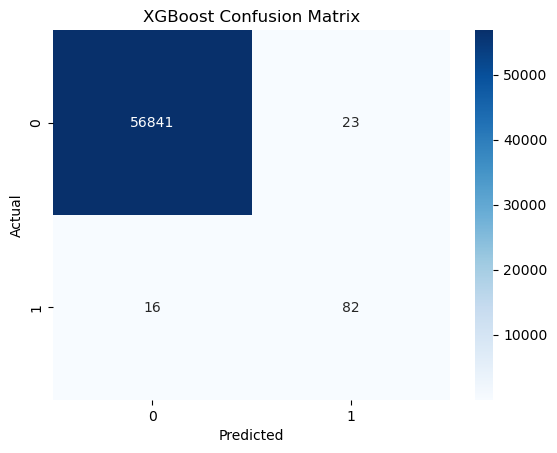

In [27]:
#confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

xgboost result

In [28]:
xgb_results = {
    "Model": "XGBoost",
    "Precision": precision_xgb,
    "Recall": recall_xgb,
    "F1": f1_xgb,
    "PR-AUC": pr_auc_xgb
}

print(xgb_results)

{'Model': 'XGBoost', 'Precision': 0.780952380952381, 'Recall': 0.8367346938775511, 'F1': 0.8078817733990148, 'PR-AUC': 0.8631180506386514}


### Tuning

In [46]:
#instantiate model
xgb_tuning = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [49]:
#define parameters
param_dist_xgb = {
    "n_estimators": randint(100, 500),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.19),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3),
    "min_child_weight": randint(1, 10)
}

In [50]:
#randomized search cv
xgb_random = RandomizedSearchCV(
    estimator=xgb_tuning,
    param_distributions=param_dist_xgb,
    n_iter=10,
    scoring="average_precision",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': <scipy.stats....0019813F8A710>, 'learning_rate': <scipy.stats....0019814AD3770>, 'max_depth': <scipy.stats....0019813FEA9C0>, 'min_child_weight': <scipy.stats....0019813FEAAD0>, ...}"
,n_iter,10
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [51]:
#best parameters
print("Best parameters:")
print(xgb_random.best_params_)

print("\nBest CV PR-AUC:")
print(xgb_random.best_score_)

Best parameters:
{'colsample_bytree': np.float64(0.9727961206236346), 'learning_rate': np.float64(0.05916819650400321), 'max_depth': 6, 'min_child_weight': 2, 'n_estimators': 489, 'subsample': np.float64(0.7623824988604566)}

Best CV PR-AUC:
0.8476282948588496


In [52]:
#evaluate tuned model
best_xgb = xgb_random.best_estimator_

y_pred_xgb_tuned = best_xgb.predict(X_test)
y_prob_xgb_tuned = best_xgb.predict_proba(X_test)[:, 1]

In [53]:
precision_xgb_tuned = precision_score(y_test, y_pred_xgb_tuned)
recall_xgb_tuned = recall_score(y_test, y_pred_xgb_tuned)
f1_xgb_tuned = f1_score(y_test, y_pred_xgb_tuned)
pr_auc_xgb_tuned = average_precision_score(y_test, y_prob_xgb_tuned)

print("Precision:", precision_xgb_tuned)
print("Recall:", recall_xgb_tuned)
print("F1-score:", f1_xgb_tuned)
print("PR-AUC:", pr_auc_xgb_tuned)

Precision: 0.8709677419354839
Recall: 0.826530612244898
F1-score: 0.8481675392670157
PR-AUC: 0.8782844796709224


In [54]:
xgb_tuned_results = {
    "Model": "XGBoost (Tuned)",
    "Precision": precision_xgb_tuned,
    "Recall": recall_xgb_tuned,
    "F1": f1_xgb_tuned,
    "PR-AUC": pr_auc_xgb_tuned
}

## 4. Isolation Forest

In [30]:
iso_forest = IsolationForest(
    n_estimators=100,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_train)

,n_estimators,100
,max_samples,'auto'
,contamination,'auto'
,max_features,1.0
,bootstrap,False
,n_jobs,-1
,random_state,42
,verbose,0
,warm_start,False


prediction

In [31]:
iso_pred = iso_forest.predict(X_test)

y_pred_iso = np.where(iso_pred == -1, 1, 0)

anomaly scores

In [32]:
iso_scores = -iso_forest.score_samples(X_test)

evaluate

In [33]:
precision_iso = precision_score(y_test, y_pred_iso)
recall_iso = recall_score(y_test, y_pred_iso)
f1_iso = f1_score(y_test, y_pred_iso)
pr_auc_iso = average_precision_score(y_test, iso_scores)

print("Precision:", precision_iso)
print("Recall:", recall_iso)
print("F1-score:", f1_iso)
print("PR-AUC:", pr_auc_iso)

Precision: 0.04217479674796748
Recall: 0.8469387755102041
F1-score: 0.0803484995159729
PR-AUC: 0.21797227754191925


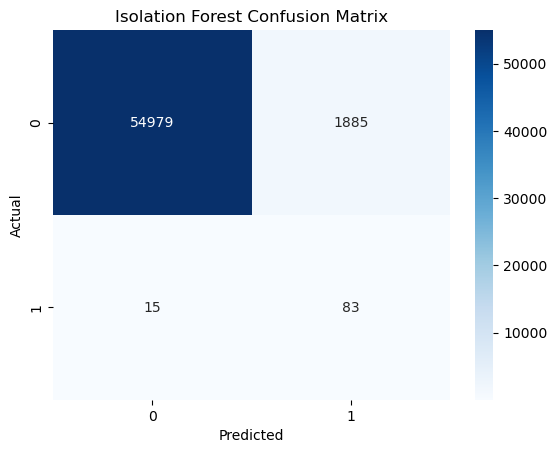

In [34]:
#confusion matrix
cm_iso = confusion_matrix(y_test, y_pred_iso)

sns.heatmap(
    cm_iso,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Isolation Forest Confusion Matrix")
plt.show()

isolation forest results

In [35]:
iso_results = {
    "Model": "Isolation Forest",
    "Precision": precision_iso,
    "Recall": recall_iso,
    "F1": f1_iso,
    "PR-AUC": pr_auc_iso
}

print(iso_results)

{'Model': 'Isolation Forest', 'Precision': 0.04217479674796748, 'Recall': 0.8469387755102041, 'F1': 0.0803484995159729, 'PR-AUC': 0.21797227754191925}


### Model comparison 

In [55]:
results = [
    baseline_results,
    rf_tuned_results,
    xgb_tuned_results,
    iso_results
]

comparison_df = pd.DataFrame(results)

comparison_df

,Model,Precision,Recall,F1,PR-AUC
0,Logistic Regression,0.060976,0.918367,0.114358,0.718971
1,Random Forest (Tuned),0.949367,0.765306,0.847458,0.865848
2,XGBoost (Tuned),0.870968,0.826531,0.848168,0.878284
3,Isolation Forest,0.042175,0.846939,0.080348,0.217972
